In [3]:
import pandas as pd  #handle the dataset
import numpy as np  #NumPy is used for numerical computation

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt


In [5]:
#This block is used to load the dataset and remove incomplete sample
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

df = pd.read_excel("synrm_rotor_dataset.xlsx")
#creates new dataframe.subset-to specify which column
df_clean = df.dropna(
    subset=[
        "H_mm", "W_mm", "R_mm", "Rb_mm", "B0_mm",
        "barriers_per_pole", "T_avg", "Torque_Ripple"
    ]
)
#isna()-check values are missing
print(df_clean.isna().sum())  # should be all zeros
#dropna()-removes rows containing missing values


H_mm                 0
W_mm                 0
R_mm                 0
Rb_mm                0
B0_mm                0
barriers_per_pole    0
T_avg                0
T_max                0
T_min                0
Torque_Ripple        0
dtype: int64


In [6]:
#x will store input features
X = df_clean[
    ["H_mm", "W_mm", "R_mm", "Rb_mm", "B0_mm", "barriers_per_pole"]
]

y_tavg = df_clean["T_avg"]
y_ripple = df_clean["Torque_Ripple"]


In [7]:
X_train, X_test, y_tavg_train, y_tavg_test, y_rip_train, y_rip_test = train_test_split(
    X, y_tavg, y_ripple,
    test_size=0.2,
    random_state=42
)


rf_tavg = RandomForestRegressor(
    n_estimators=400,
    max_depth=30, #Controls overfitting
    max_features=2,
    min_samples_leaf=1, #Allows very fine splits,Helps capture small design variations
    min_samples_split=2, 
    random_state=42 #make the results reproducible by fixing the  randomnes
)

rf_ripple = RandomForestRegressor(
    n_estimators=400,
    max_depth=30,
    max_features=2,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

rf_tavg.fit(X_train, y_tavg_train)
rf_ripple.fit(X_train, y_rip_train)

print("✅ Models trained with tuned hyperparameters")

✅ Models trained with tuned hyperparameters


In [9]:
from sklearn.metrics import mean_absolute_error

pred_tavg = rf_tavg.predict(X_test)
pred_ripple = rf_ripple.predict(X_test)

print("Average Torque Model")
print("R2   :", r2_score(y_tavg_test, pred_tavg))
print("RMSE :", np.sqrt(mean_squared_error(y_tavg_test, pred_tavg)))
print("MAE  :", mean_absolute_error(y_tavg_test, pred_tavg))

print("\nTorque Ripple Model")
print("R2   :", r2_score(y_rip_test, pred_ripple))
print("RMSE :", np.sqrt(mean_squared_error(y_rip_test, pred_ripple)))
print("MAE  :", mean_absolute_error(y_rip_test, pred_ripple))


Average Torque Model
R2   : 0.9833474149555548
RMSE : 0.7285836791945748
MAE  : 0.34798483562745725

Torque Ripple Model
R2   : 0.9900846115292663
RMSE : 0.09198774036144072
MAE  : 0.06671949233376698


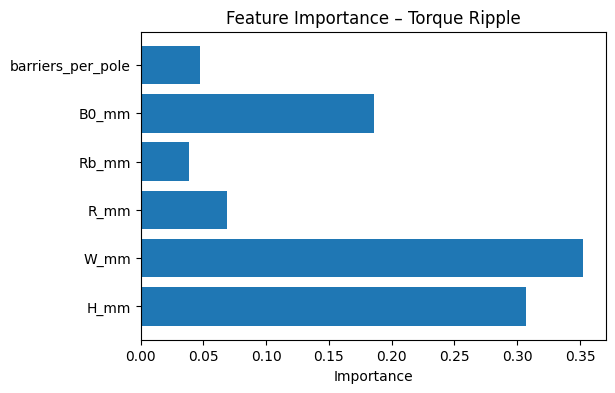

In [7]:
plt.figure(figsize=(6,4))
plt.barh(X.columns, rf_ripple.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance – Torque Ripple")
plt.show()


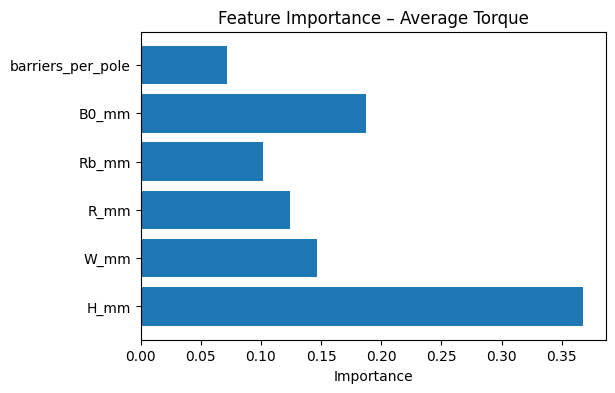

In [29]:
plt.figure(figsize=(6,4))
plt.barh(X.columns, rf_tavg.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance – Average Torque")
plt.show()


In [10]:
import pandas as pd

print("\n--- PREDICTION MODEL (USER INPUT) ---")

# Take input from user
H_mm = float(input("Enter Barrier Height H_mm: "))
W_mm = float(input("Enter Barrier Width W_mm: "))
R_mm = float(input("Enter Fillet Radius R_mm: "))
Rb_mm = float(input("Enter Bottom Barrier Radius Rb_mm: "))
B0_mm = float(input("Enter Barrier Offset B0_mm: "))
barriers_per_pole = int(input("Enter Number of Barriers per Pole: "))

# Create dataframe for prediction
user_input = pd.DataFrame({
    "H_mm": [H_mm],
    "W_mm": [W_mm],
    "R_mm": [R_mm],
    "Rb_mm": [Rb_mm],
    "B0_mm": [B0_mm],
    "barriers_per_pole": [barriers_per_pole]
})

# Predict using trained Random Forest models
predicted_tavg = rf_tavg.predict(user_input)
predicted_ripple = rf_ripple.predict(user_input)

# Output results
print("\n--- PREDICTION RESULTS ---")
print("Predicted Average Torque :", predicted_tavg[0])
print("Predicted Torque Ripple (scaled 5–9) :", predicted_ripple[0])



--- PREDICTION MODEL (USER INPUT) ---
Enter Barrier Height H_mm: 1.852785
Enter Barrier Width W_mm: 2.289263
Enter Fillet Radius R_mm: 1.017259
Enter Bottom Barrier Radius Rb_mm: 22.436783
Enter Barrier Offset B0_mm: 4.585361
Enter Number of Barriers per Pole: 3

--- PREDICTION RESULTS ---
Predicted Average Torque : 18.58902382499457
Predicted Torque Ripple (scaled 5–9) : 5.1201253926834145


In [34]:
from sklearn.metrics import r2_score
import numpy as np

r2_tavg = r2_score(y_tavg_test, pred_tavg)
r2_ripple = r2_score(y_rip_test, pred_ripple)

print("R2 Average Torque :", r2_tavg)
print("R2 Torque Ripple  :", r2_ripple)


R2 Average Torque : 0.9833474149555548
R2 Torque Ripple  : 0.9900846115292663


In [11]:
import pandas as pd
import numpy as np

# Load dataset (same one used for RF)
df = pd.read_excel("synrm_rotor_dataset.xlsx")

df.head() #Displays the first 5 rows of the dataset


,H_mm,W_mm,R_mm,Rb_mm,B0_mm,barriers_per_pole,T_avg,T_max,T_min,Torque_Ripple
0,2.8846,2.6224,0.2847,21.8002,5.4617,3,6.1988,14.3617,-0.0009,5.873598
1,2.3303,1.0662,1.2567,24.2201,1.1642,2,4.0155,11.0629,0.0000,6.250183
2,4.2570,3.5550,2.2007,20.9001,4.7947,2,5.8143,9.6501,-0.0147,5.310720
3,1.4765,4.5654,1.3585,25.5857,2.2718,4,9.7892,15.3898,-3.4986,5.540485
4,4.6946,3.5031,0.2019,18.9547,4.4459,3,5.4782,8.8434,-0.0174,5.272223


In [12]:
import numpy as np
import pandas as pd
#creates dictionary-design space for optimization,defines the allowed range of each rotor design variable
#Prevents unrealistic designs
bounds = {
    "H_mm": (df["H_mm"].min(), df["H_mm"].max()),
    "W_mm": (df["W_mm"].min(), df["W_mm"].max()),
    "R_mm": (df["R_mm"].min(), df["R_mm"].max()),
    "Rb_mm": (df["Rb_mm"].min(), df["Rb_mm"].max()),
    "B0_mm": (df["B0_mm"].min(), df["B0_mm"].max()),
    "barriers_per_pole": (2, 4)
}


def fitness_function(individual):
    #Converts the design vector into a DataFrame
    #Needed because Random Forest expects DataFrame input
    df_ind = pd.DataFrame([individual], columns=[
        "H_mm", "W_mm", "R_mm", "Rb_mm", "B0_mm", "barriers_per_pole"
    ])

    # RF predictions,Uses trained Random Forest model
    tavg = rf_tavg.predict(df_ind)[0]
    ripple = rf_ripple.predict(df_ind)[0]   
    # Strong penalty for ripple
    fitness = tavg - 4.0 * ripple

    # Hard constraint: push ripple to minimum zone
    #Constraint handling using penalty method
    if ripple > 5.3:
        fitness -= 100

    return fitness  #Returns final fitness score,GA uses this to:Select,Crossover,Mutate designs

#Used to create initial population for GA,Generates one random rotor design
def create_individual():
    return [
        np.random.uniform(*bounds["H_mm"]),
        np.random.uniform(*bounds["W_mm"]),
        np.random.uniform(*bounds["R_mm"]),
        np.random.uniform(*bounds["Rb_mm"]),
        np.random.uniform(*bounds["B0_mm"]),
        np.random.randint(bounds["barriers_per_pole"][0],
                          bounds["barriers_per_pole"][1] + 1) #+1 because upper limit is exclusive in randint
    ]


In [13]:
#Used to select one parent from the population
#RANDOMLY PICK k CANDIDATES
def tournament_selection(population, k=3):
    selected = np.random.choice(len(population), k, replace=False)
    best = max(selected, key=lambda i: fitness_function(population[i]))  #FIND THE BEST AMONG THEM
    return population[best]


In [14]:
def crossover(p1, p2):     #Combine good traits of two good designs
    child = []
    for i in range(len(p1)):
        if i == 5:  # integer gene    #this variable must be integer,So you cannot average it,This preserves valid discrete values
            child.append(p1[i] if np.random.rand() < 0.5 else p2[i])
        else:
            child.append((p1[i] + p2[i]) / 2)    #Arithmetic crossover-for smooth geometric changes
    return child


In [15]:
def mutate(individual, mutation_rate=0.1):   #Purpose: introduce randomness,Explores entire design space
    for i in range(len(individual)):
        if np.random.rand() < mutation_rate:   #If it is less than 0.1,Mutate this gene
            if i == 5:  
                individual[i] = np.random.randint(          
                    bounds["barriers_per_pole"][0],
                    bounds["barriers_per_pole"][1] + 1
                )
            else:
                key = list(bounds.keys())[i]   #Finds the parameter name corresponding to index i
                individual[i] = np.random.uniform(*bounds[key])  #It replaces one parameter of the individual with a new random value inside its allowed range
    return individual


In [16]:
population_size = 40
population = [create_individual() for _ in range(population_size)]

generations = 50

best_solution = None
best_fitness = -np.inf

for gen in range(generations):
    new_population = []        #Stores next generation individuals

    for _ in range(population_size):
        p1 = tournament_selection(population)      #Selects two parents,Tournament selection ensures,Better designs are more likely chosen

Diversity is maintained
        p2 = tournament_selection(population)

        child = crossover(p1, p2)    #child = crossover(p1, p2)

        child = mutate(child)        #Randomly alters some genes

        new_population.append(child)     #Child becomes part of next generation

        f = fitness_function(child)
        if f > best_fitness:                      #Checks if current child is best ever
            best_fitness = f
            best_solution = child

    population = new_population           #Old population is replaced

    if gen % 5 == 0:                           #Prints progress every 5 generations
        print(f"Generation {gen+1}, Best Fitness = {best_fitness:.3f}")              #.3f → 3 decimal precision


Generation 1, Best Fitness = -106.869
Generation 6, Best Fitness = -5.710
Generation 11, Best Fitness = -4.906
Generation 16, Best Fitness = -2.812
Generation 21, Best Fitness = -2.606
Generation 26, Best Fitness = -1.859
Generation 31, Best Fitness = -1.859
Generation 36, Best Fitness = -1.859
Generation 41, Best Fitness = -1.859
Generation 46, Best Fitness = -1.859


In [15]:
opt_df = pd.DataFrame([best_solution], columns=[                     #Converts best_solution (a list) into a Pandas DataFrame
    "H_mm", "W_mm", "R_mm", "Rb_mm", "B0_mm", "barriers_per_pole"
])

opt_tavg = rf_tavg.predict(opt_df)[0]
opt_ripple = rf_ripple.predict(opt_df)[0]

print("\n--- OPTIMIZED ROTOR DESIGN ---")
print(opt_df)
print("Predicted Average Torque :", opt_tavg)
print("Predicted Torque Ripple  :", opt_ripple)



--- OPTIMIZED ROTOR DESIGN ---
       H_mm      W_mm      R_mm      Rb_mm     B0_mm  barriers_per_pole
0  1.852785  2.289263  1.017259  22.436783  4.585361                  3
Predicted Average Torque : 18.58902382499457
Predicted Torque Ripple  : 5.1201253926834145
